
=== Training on Debian → Testing on Chrome ===
Debian dataset shape: (18298, 1024)
Chrome dataset shape: (4436, 1024)

Testing TensorFlow speed...
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5080 - loss: 0.6930
TensorFlow test finished


=== Ensemble Iteration 1/3 ===

Training Neural Network on Debian...
Epoch 1/50
Processing batch 0
 49/229 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5720 - loss: 0.6995Processing batch 50
 97/229 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5733 - loss: 0.6998Processing batch 100
149/229 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5737 - loss: 0.6996Processing batch 150
197/229 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5748 - loss: 0.6970Processing batch 200
229/229 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5786 - loss: 0.6878 - val_accuracy: 0.5571 - val_loss: 0.6514
Epoch 2/50
Processing batch 0
 49/229 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5792 - loss: 0.6520Processing batch 50
 97/229 ━━━━━━━━━━━━━━━━━━

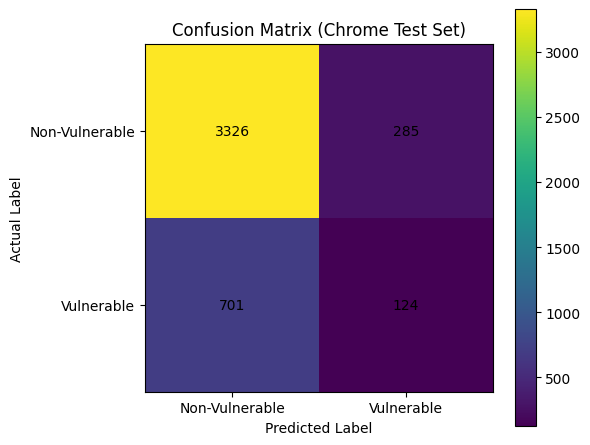

In [3]:
"""
Cross-Project Vulnerability Detection
-------------------------------------
Train on Debian → Test on Chrome
"""

# =========================================================
# Imports
# =========================================================

import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import Callback

warnings.filterwarnings("ignore")

# =========================================================
# TensorFlow Configuration
# =========================================================

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

tf.config.run_functions_eagerly(True)

tf.config.threading.set_inter_op_parallelism_threads(0)
tf.config.threading.set_intra_op_parallelism_threads(0)

os.environ["OMP_NUM_THREADS"] = "8"

# =========================================================
# Progress Logger
# =========================================================

class BatchLogger(Callback):

    def on_train_batch_begin(self, batch, logs=None):

        if batch % 50 == 0:
            print(f"Processing batch {batch}")


# =========================================================
# Reproducibility
# =========================================================

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

os.environ["PYTHONHASHSEED"] = str(seed)

# =========================================================
# Original Configuration
# =========================================================

EPOCHS_INITIAL = 50
EPOCHS_RETRAIN = 30

BATCH_SIZE_INITIAL = 64
BATCH_SIZE_RETRAIN = 32

LEARNING_RATE = 1e-5
NUM_ITERATIONS = 3

# =========================================================
# Neural Network Model
# =========================================================

def create_neural_network(input_dim: int):

    model = Sequential([
        Dense(256, activation="relu", input_dim=input_dim),
        Dropout(0.2),

        Dense(128, activation="relu"),
        Dropout(0.2),

        Dense(64, activation="relu"),
        Dropout(0.2),

        Dense(32, activation="relu"),
        Dropout(0.2),

        Dense(16, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================================
# Semi-supervised Transfer Learning
# =========================================================

def semi_supervised_transfer_learning(
        x_train,
        y_train,
        x_test,
        class_weight_dict):

    model = create_neural_network(x_train.shape[1])

    print("\nTraining Neural Network on Debian...")

    model.fit(
        x_train,
        y_train,
        epochs=EPOCHS_INITIAL,
        batch_size=BATCH_SIZE_INITIAL,
        validation_split=0.2,
        class_weight=class_weight_dict,
        callbacks=[BatchLogger()],
        verbose=1
    )

    print("\nGenerating pseudo labels for Chrome dataset...")

    y_pred = model.predict(x_test, verbose=0)

    y_pred_binary = (y_pred > 0.5).astype(int).flatten()

    x_train_aug = np.concatenate((x_train, x_test))
    y_train_aug = np.concatenate((y_train, y_pred_binary))

    print("\nRetraining model with pseudo-labelled Chrome data...")

    model.fit(
        x_train_aug,
        y_train_aug,
        epochs=EPOCHS_RETRAIN,
        batch_size=BATCH_SIZE_RETRAIN,
        class_weight=class_weight_dict,
        verbose=1
    )

    return model, y_pred.flatten()


# =========================================================
# XGBoost Model
# =========================================================

def train_base_model_xgb(
        x_train,
        y_train,
        sample_weights=None):

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        use_label_encoder=False,
        eval_metric="logloss"
    )

    model.fit(
        x_train,
        y_train,
        sample_weight=sample_weights
    )

    return model


# =========================================================
# Main Pipeline
# =========================================================

def main():

    print("\n=== Training on Debian → Testing on Chrome ===")

    # -----------------------------------------------------
    # Load Embeddings
    # -----------------------------------------------------

    deb_emb = np.load("dataset/debian_embeddings.npy")
    deb_lbl = np.load("dataset/debian_labels.npy")

    chr_emb = np.load("dataset/chrome_embeddings.npy")
    chr_lbl = np.load("dataset/chrome_labels.npy")

    deb_emb = deb_emb.astype(np.float32)
    chr_emb = chr_emb.astype(np.float32)

    deb_lbl = deb_lbl.astype(np.float32)
    chr_lbl = chr_lbl.astype(np.float32)

    print("Debian dataset shape:", deb_emb.shape)
    print("Chrome dataset shape:", chr_emb.shape)

    # -----------------------------------------------------
    # TensorFlow Speed Test
    # -----------------------------------------------------

    print("\nTesting TensorFlow speed...")

    dummy_model = create_neural_network(1024)

    dummy_x = np.random.rand(1000, 1024).astype(np.float32)
    dummy_y = np.random.randint(0, 2, 1000)

    dummy_model.fit(dummy_x, dummy_y, epochs=1, batch_size=32)

    print("TensorFlow test finished\n")

    # -----------------------------------------------------
    # Normalize Features
    # -----------------------------------------------------

    scaler = StandardScaler()

    deb_emb = scaler.fit_transform(deb_emb)
    chr_emb = scaler.transform(chr_emb)

    # -----------------------------------------------------
    # Compute Class Weights
    # -----------------------------------------------------

    classes = np.unique(deb_lbl)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=deb_lbl
    )

    class_weight_dict = {
        cls: w for cls, w in zip(classes, class_weights)
    }

    # -----------------------------------------------------
    # Ensemble Training
    # -----------------------------------------------------

    ensemble_predictions = np.zeros(len(chr_lbl))

    for i in range(NUM_ITERATIONS):

        print(f"\n=== Ensemble Iteration {i+1}/{NUM_ITERATIONS} ===")

        model_nn, _ = semi_supervised_transfer_learning(
            deb_emb,
            deb_lbl,
            chr_emb,
            class_weight_dict
        )

        print("\nComputing confidence-based weights...")

        y_train_pred = model_nn.predict(
            deb_emb,
            verbose=0
        ).flatten()

        sample_weights = np.where(
            deb_lbl == 1,
            y_train_pred,
            1 - y_train_pred
        )

        print("Training XGBoost model...")

        model_xgb = train_base_model_xgb(
            deb_emb,
            deb_lbl,
            sample_weights
        )

        print("Predicting Chrome dataset...")

        model_xgb_pred = model_xgb.predict(chr_emb)

        ensemble_predictions += model_xgb_pred

    # -----------------------------------------------------
    # Average Predictions
    # -----------------------------------------------------

    ensemble_avg = ensemble_predictions / NUM_ITERATIONS

    y_pred_final = (ensemble_avg > 0.5).astype(int)

    # -----------------------------------------------------
    # Evaluation Metrics
    # -----------------------------------------------------

    accuracy = accuracy_score(chr_lbl, y_pred_final)
    recall = recall_score(chr_lbl, y_pred_final)
    precision = precision_score(chr_lbl, y_pred_final)
    auc = roc_auc_score(chr_lbl, ensemble_avg)
    f1 = f1_score(chr_lbl, y_pred_final)

    tn, fp, fn, tp = confusion_matrix(
        chr_lbl,
        y_pred_final
    ).ravel()

    g_mean = np.sqrt(tp / (tp + fn))
    pf = fp / (fp + tn)

    print("\n=== Evaluation Results (Chrome Test Set) ===")

    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"AUC:       {auc:.3f}")
    print(f"G-mean:    {g_mean:.3f}")
    print(f"PF value:  {pf:.3f}")

    print("\nConfusion Matrix:")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")

    # -----------------------------------------------------
    # Plot Confusion Matrix
    # -----------------------------------------------------

    cm = confusion_matrix(chr_lbl, y_pred_final)

    plt.figure(figsize=(6, 5))

    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Chrome Test Set)")
    plt.colorbar()

    tick_marks = np.arange(2)

    plt.xticks(
        tick_marks,
        ["Non-Vulnerable", "Vulnerable"]
    )

    plt.yticks(
        tick_marks,
        ["Non-Vulnerable", "Vulnerable"]
    )

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()


# =========================================================

if __name__ == "__main__":
    main()